# Compute metrics

F1, recall, precision, mean IoU, mean Dice, PQ

Save metrics as:

results/experiment_metrics.csv


In [ ]:
1+1

2

In [2]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy
import skimage
import scipy
import basicpy
from tqdm import tqdm

import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')

from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp

%load_ext autoreload
%autoreload 2

In [3]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')
# organoid_sam = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


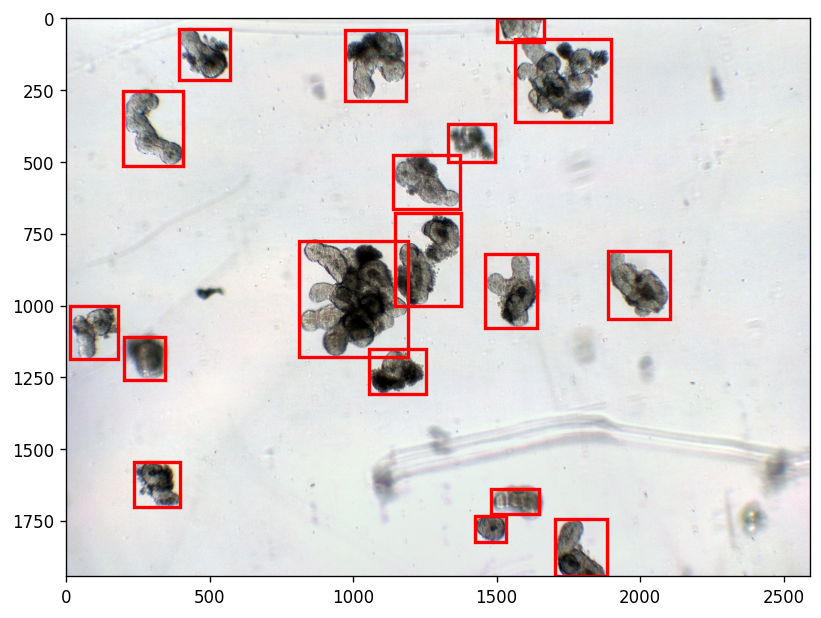

In [4]:
ds = dl.OrganoID(split='test_only_mouse')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

In [5]:
split = 'test'
pred_folder = Path(f'/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM2_large/{split}/{str(ds)}_{ds.split}/DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46')
pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, f'{str(ds)}_{ds.split}', pred_folder, im, im_ID)

In [6]:
pred_masks.shape

(400, 1944, 2592)

In [7]:
(pred_masks.sum(axis=(1, 2)) < 100).sum()

3

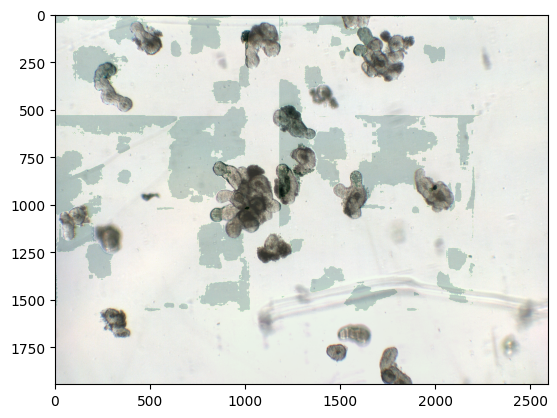

In [8]:
plt.imshow(im)
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255, alpha=0.2, cmap='YlGn')

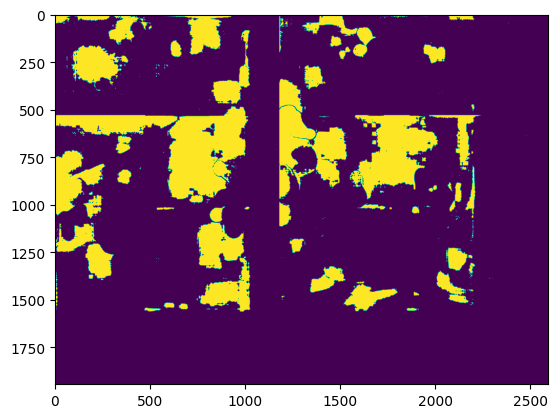

In [9]:
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255)

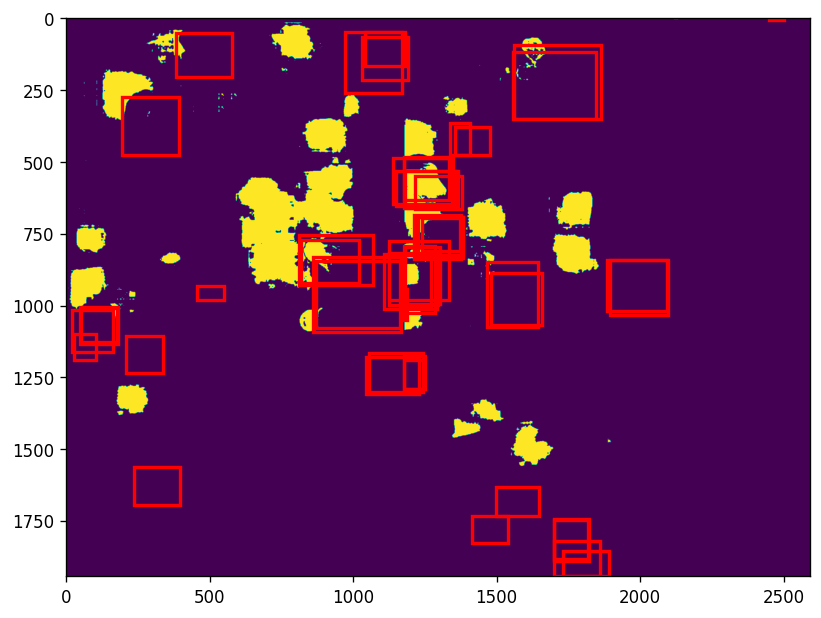

In [10]:
plot_boxes(np.any(pred_masks[pred_scores > 0.9], axis=0).astype(int) * 255, pred_boxes[pred_scores > 0.9], format='yxyx_px')
# plt.imshow(im)

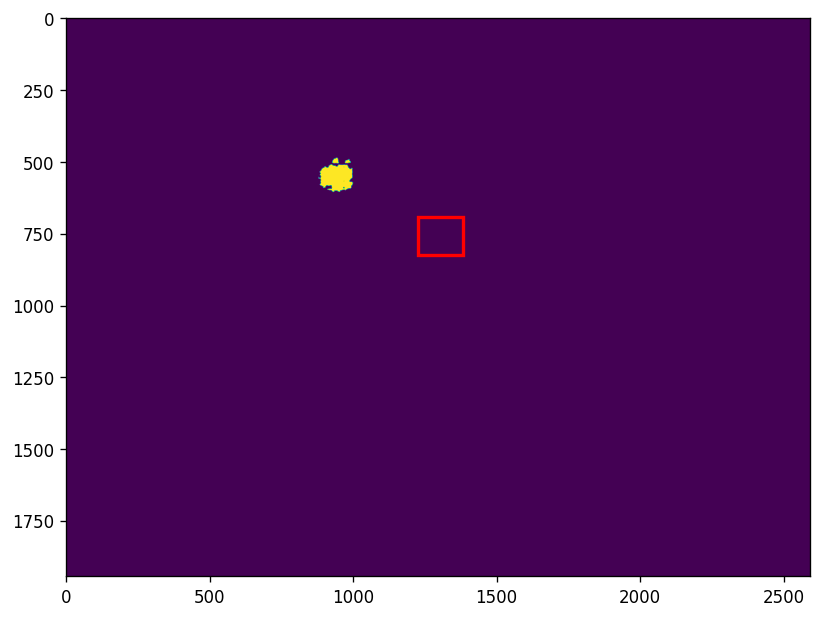

In [12]:
i = 5
plot_boxes(pred_masks[pred_scores > 0.9][i].astype(int) * 255, pred_boxes[pred_scores > 0.9][i:i+1], format='yxyx_px')
# plt.imshow(im)

## Tune threshold

In [ ]:

# NMS threshold
from tqdm import tqdm

nms_thres = 0.5


experiment_name = 'sam_variants'
experiment = [
    ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.37', 'MedSAM_last', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.42', 'MicroSAM_huge_last', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.55', 'MicroSAM_large_last', 'val', dl.OrganoID(split='val')),
    # ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46', 'SAM2_large_last', 'val', dl.OrganoID(split='val')),
    ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.22', 'SAM_base_last', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.82', 'MicroSAM_base_last', 'val', dl.OrganoID(split='val')),
    ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.76', 'CellSAM_last', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'SAM_large_last', 'val', dl.OrganoID(split='val')),

    ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=299-val_loss=11.35', 'MedSAM_best', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=199-val_loss=8.26', 'MicroSAM_huge_best', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=249-val_loss=8.47', 'MicroSAM_large_best', 'val', dl.OrganoID(split='val')),
    # ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=7.18', 'SAM2_large_best', 'val', dl.OrganoID(split='val')),
    ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=8.02', 'SAM_base_best', 'val', dl.OrganoID(split='val')),
    ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=399-val_loss=8.80', 'MicroSAM_base_best', 'val', dl.OrganoID(split='val')),
    ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=499-val_loss=11.76', 'CellSAM_best', 'val', dl.OrganoID(split='val')),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'SAM_large_best', 'val', dl.OrganoID(split='val')),
]


df = []

for backbone, ckpt_name, model_name, split, test_data in experiment:
    ds_name = f'{str(test_data)}_{test_data.split}'
    
    pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
    for im, mask, boxes, im_path, im_ID in tqdm(test_data):
        gt_masks = pp.convert_mask_to_binary(mask)

        # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
        # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
        # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
        # pred_boxes = pred_boxes[:min_shape]
        # pred_masks = pred_masks[:min_shape]
        # pred_scores = pred_scores[:min_shape]

        # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
        pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)

        # print(pred_boxes.shape, boxes.shape)

        keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
        pred_boxes = pred_boxes[keep_masks]
        pred_masks = pred_masks[keep_masks]
        pred_scores = pred_scores[keep_masks]
        
        # print(pred_boxes.shape, boxes.shape)

        # Filter most unrealistic ones
        # lowest_score = 0.5
        sorted_scores = np.sort(pred_scores, axis=None)
        if len(sorted_scores) < 300:
            lowest_score = 0.0
        else:
            lowest_score = np.round(sorted_scores[-300], decimals=2) 
        print(lowest_score)
        if lowest_score > 0.95:
            print('\n##### Skipping evaluation due to very high score threshold. #####\n')
            continue

        pred_boxes = pred_boxes[pred_scores >= lowest_score]
        pred_masks = pred_masks[pred_scores >= lowest_score]
        pred_scores = pred_scores[pred_scores >= lowest_score]
        
        # print(pred_boxes.shape, boxes.shape)

        iou_matrix_detection = pp.compute_iou_matrix_detection(pred_boxes, gt_boxes=boxes)
        # print('after det')
        iou_matrix_segmentation = pp.compute_iou_matrix_segmentation(pred_masks, gt_masks)
        # print('after seg')
        
        for confidence_thres in tqdm(np.arange(0.0, 1.0, 0.01)): 
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            _pred_boxes = pred_boxes[pred_scores >= confidence_thres]
            _pred_scores = pred_scores[pred_scores >= confidence_thres]
            _iou_matrix_detection = iou_matrix_detection[pred_scores >= confidence_thres]
            _iou_matrix_segmentation = iou_matrix_segmentation[pred_scores >= confidence_thres]
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(_pred_boxes, _pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                _iou_matrix_detection = _iou_matrix_detection[kept_indices]
                _iou_matrix_segmentation = _iou_matrix_segmentation[kept_indices]

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation_from_iou_matrix(
                    iou_matrix=_iou_matrix_segmentation, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'segmentation', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection_from_iou_matrix(
                    iou_matrix=_iou_matrix_detection, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'detection', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
    df_partial = pd.DataFrame(data=df, columns=[
        'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
        'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
    ])
    df_partial.to_csv(results_dir / f'thres_tuning_{experiment_name}_partial.csv')

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'thres_tuning_{experiment_name}.csv')
df

  0%|                                                                           | 0/14 [00:00<?, ?it/s]

0.06


  7%|████▊                                                              | 1/14 [00:57<12:26, 57.46s/it]

0.07


 14%|█████████▌                                                         | 2/14 [01:26<08:07, 40.60s/it]

...

0.46


 64%|███████████████████████████████████████████                        | 9/14 [04:38<01:42, 20.51s/it]

0.58


 71%|███████████████████████████████████████████████▏                  | 10/14 [05:09<01:34, 23.71s/it]

0.88


In [13]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres'], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,confidence_thres,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,orgasegment_comparison,OrgaSegment_val,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.00,0.000000,0.334911,0.874291,0.474354,0.764567,0.000000
1,orgasegment_comparison,OrgaSegment_val,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.01,0.000000,0.339035,0.874291,0.479014,0.764567,0.000000
2,orgasegment_comparison,OrgaSegment_val,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.02,0.000000,0.345082,0.873799,0.485700,0.764565,0.000000
3,orgasegment_comparison,OrgaSegment_val,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.03,0.000000,0.352365,0.873799,0.494049,0.764565,0.000000
4,orgasegment_comparison,OrgaSegment_val,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.04,0.000000,0.358399,0.873799,0.500592,0.764472,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,orgasegment_comparison,OrgaSegment_val,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.95,0.616861,0.683764,0.842870,0.740753,0.833053,0.905630
1596,orgasegment_comparison,OrgaSegment_val,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.96,0.617517,0.690939,0.833044,0.741078,0.833494,0.905895
1597,orgasegment_comparison,OrgaSegment_val,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.97,0.618895,0.703431,0.816485,0.742439,0.833811,0.906125
1598,orgasegment_comparison,OrgaSegment_val,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.98,0.621931,0.723032,0.798493,0.745749,0.834142,0.906288


In [14]:
det_df = metrics.loc[metrics.metric_type == 'detection']
det_df_max = det_df.groupby(['model_name', 'ckpt_name'], as_index=False).agg(
    max_f1 = ('f1_score_mean', 'max')
    #lambda x: x[x['f1_score_mean'] == x['f1_score_mean'].max(), 'confidence_thres'].item()
)
det_df = det_df.join(det_df_max.set_index(['model_name', 'ckpt_name']), on=['model_name', 'ckpt_name'], how='left')
best_thres_df = det_df.loc[det_df['f1_score_mean'] == det_df['max_f1'], ['model_name', 'confidence_thres', 'max_f1']]
best_thres_df

,model_name,confidence_thres,max_f1
93,no_pretraining_best,0.93,0.667972
194,no_pretraining_last,0.94,0.673972
296,NeurIPS_best,0.96,0.698021
397,NeurIPS_last,0.97,0.713149
497,OI_best,0.97,0.715366
596,OI_last,0.96,0.714894
695,OI_and_NeurIPS_best,0.95,0.733254
798,OI_and_NeurIPS_last,0.98,0.737741


# Predict

boxes, scores and masks are saved in a folder called 'organoid_sam/patch_predictions/backbone/trainvaltest/dataset_name/checkpoint_name/image_ID/boxes_{i}.npy'

In [15]:
best_thres_df

,model_name,confidence_thres,max_f1
93,no_pretraining_best,0.93,0.667972
194,no_pretraining_last,0.94,0.673972
296,NeurIPS_best,0.96,0.698021
397,NeurIPS_last,0.97,0.713149
497,OI_best,0.97,0.715366
596,OI_last,0.96,0.714894
695,OI_and_NeurIPS_best,0.95,0.733254
798,OI_and_NeurIPS_last,0.98,0.737741


In [ ]:

# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment_name = 'sam_variants'
experiment = [
    ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.37', 'MedSAM_last'),
    ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.42', 'MicroSAM_huge_last'),
    ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.55', 'MicroSAM_large_last'),
    ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46', 'SAM2_large_last'),
    ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.22', 'SAM_base_last'),
    ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.82', 'MicroSAM_base_last'),
    ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.76', 'CellSAM_last'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'SAM_large_last'),

    ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=299-val_loss=11.35', 'MedSAM_best'),
    ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=199-val_loss=8.26', 'MicroSAM_huge_best'),
    ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=249-val_loss=8.47', 'MicroSAM_large_best'),
    ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=7.18', 'SAM2_large_best'),
    ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=8.02', 'SAM_base_best'),
    ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=399-val_loss=8.80', 'MicroSAM_base_best'),
    ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=499-val_loss=11.76', 'CellSAM_best'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'SAM_large_best'),
]


df = []
for split, test_data in [('test', dl.OrganoID(split='test')),
                    ('test', dl.OrganoID(split='test_Lung')),
                    ('test', dl.OrganoID(split='test_ACC')),
                    ('test', dl.OrganoID(split='test_C')),
                    ('test', dl.OrganoID(split='test_only_mouse'))]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = float(best_thres_df.loc[best_thres_df['model_name'] == model_name, 'confidence_thres'].item())
        print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            gt_masks = pp.convert_mask_to_binary(mask)

            # print(boxes.shape, gt_masks.shape)


            # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
            # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
            # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
            # pred_boxes = pred_boxes[:min_shape]
            # pred_masks = pred_masks[:min_shape]
            # pred_scores = pred_scores[:min_shape]

            # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_patch_numbers = pred_patch_numbers[pred_scores >= optimal_thres]
            pred_offsets = pred_offsets[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                pred_boxes = pred_boxes[kept_indices]
                pred_masks = pred_masks[kept_indices]
                pred_patch_numbers = pred_patch_numbers[kept_indices]
                pred_offsets = pred_offsets[kept_indices]
                pred_scores = pred_scores[kept_indices]

                pred_masks, pred_boxes, pred_scores = pp.stitch(pred_masks, 
                                                                pred_patch_numbers, 
                                                                pred_offsets, 
                                                                pred_boxes, 
                                                                pred_scores)

                assert pred_boxes.ndim == 2, pred_boxes.shape
                assert pred_boxes.shape[1] == 4, pred_boxes.shape
                assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
                assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation(pred_masks=pred_masks, 
                                                                                                                       gt_masks=gt_masks, 
                                                                                                                       iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                    gt_boxes=boxes, 
                                                                                                                    iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')
df

0.94


100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [02:11<00:00, 13.18s/it]


0.97


100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:50<00:00, 11.03s/it]


0.96


...

0.97


100%|████████████████████████████████████████████████████████████████████████████████| 4/4 [01:09<00:00, 17.25s/it]


0.95


100%|████████████████████████████████████████████████████████████████████████████████| 4/4 [01:42<00:00, 25.62s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,orgasegment_comparison,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.94,28,19,152,0.208922,0.595745,0.155556,0.246696,0.846881,0.913783
1,orgasegment_comparison,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.94,25,22,155,0.000000,0.531915,0.138889,0.220264,0.687416,0.000000
2,orgasegment_comparison,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.94,34,15,45,0.456563,0.693878,0.430380,0.531250,0.859412,0.921287
3,orgasegment_comparison,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.94,28,21,51,0.000000,0.571429,0.354430,0.437500,0.670399,0.000000
4,orgasegment_comparison,OrganoID_test,PDAC2,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.94,36,15,18,0.575438,0.705882,0.666667,0.685714,0.839180,0.908690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,orgasegment_comparison,OrganoID_test_mouse,b_image0009,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.95,14,10,4,0.000000,0.583333,0.777778,0.666667,0.787689,0.000000
508,orgasegment_comparison,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.95,43,44,39,0.387660,0.494253,0.524390,0.508876,0.761797,0.858729
509,orgasegment_comparison,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.95,38,49,44,0.000000,0.436782,0.463415,0.449704,0.651802,0.000000
510,orgasegment_comparison,OrganoID_test_mouse,image0017,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.95,15,6,3,0.672289,0.714286,0.833333,0.769231,0.873975,0.930844


In [17]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.000000,0.565898,0.470829,0.486638,0.715293,0.000000
1,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.000000,0.592947,0.488204,0.511908,0.712827,0.000000
2,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_best,0.000000,0.697032,0.468219,0.542019,0.735094,0.000000
3,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_last,0.000000,0.713663,0.442126,0.528173,0.729683,0.000000
4,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_best,0.000000,0.717021,0.491438,0.547886,0.742746,0.000000
5,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_last,0.000000,0.689223,0.474995,0.529849,0.746580,0.000000
6,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.000000,0.693883,0.573620,0.599545,0.749804,0.000000
7,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.000000,0.717243,0.511939,0.571156,0.763583,0.000000
8,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.467015,0.663297,0.559374,0.572911,0.814171,0.892117
9,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.471971,0.670629,0.552170,0.578963,0.818058,0.894790


In [18]:
metrics.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_aggregated.csv')
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.000000,0.565898,0.470829,0.486638,0.715293,0.000000
1,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.000000,0.592947,0.488204,0.511908,0.712827,0.000000
2,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_best,0.000000,0.697032,0.468219,0.542019,0.735094,0.000000
3,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_last,0.000000,0.713663,0.442126,0.528173,0.729683,0.000000
4,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_best,0.000000,0.717021,0.491438,0.547886,0.742746,0.000000
5,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_last,0.000000,0.689223,0.474995,0.529849,0.746580,0.000000
6,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.000000,0.693883,0.573620,0.599545,0.749804,0.000000
7,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.000000,0.717243,0.511939,0.571156,0.763583,0.000000
8,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.467015,0.663297,0.559374,0.572911,0.814171,0.892117
9,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.471971,0.670629,0.552170,0.578963,0.818058,0.894790


In [19]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
NeurIPS_best,0.503137,0.581077,0.585002,0.740710,0.516816
NeurIPS_last,0.478879,0.582323,0.586035,0.697909,0.493665
OI_and_NeurIPS_best,0.527441,0.645208,0.600952,0.737434,0.562172
OI_and_NeurIPS_last,0.525995,0.549942,0.603120,0.700072,0.545455
OI_best,0.489786,0.583585,0.554654,0.744905,0.448335
OI_last,0.481491,0.563577,0.610810,0.724341,0.461047
no_pretraining_best,0.467015,0.596138,0.573987,0.734937,0.461055
no_pretraining_last,0.471971,0.584889,0.573058,0.726909,0.454156


In [21]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
NeurIPS_best,0.605417,0.653960,0.709378,0.831107,0.631126
NeurIPS_last,0.575721,0.664227,0.715703,0.793908,0.583059
OI_and_NeurIPS_best,0.638954,0.731067,0.715614,0.823282,0.666253
OI_and_NeurIPS_last,0.640066,0.613796,0.734521,0.777030,0.631638
OI_best,0.590980,0.662853,0.652269,0.826837,0.529067
OI_last,0.582083,0.645287,0.720789,0.804504,0.546579
no_pretraining_best,0.572911,0.684826,0.687528,0.824192,0.573953
no_pretraining_last,0.578963,0.666958,0.687285,0.814059,0.566766


### Plots